In [17]:
import os, copy
import numpy as np
import jax
import jax.numpy as jnp
from jax import vmap
import matplotlib.pyplot as plt
import pandas as pd
import interpax
from scipy.interpolate import interp1d

from jax_cosmo import Cosmology
import jax_cosmo.background as bkgrd
from jax_cosmo.background import radial_comoving_distance

from godmax.get_Cls  import get_Cl
from godmax.get_covs import get_cov
from godmax.base_class import get_vmapped_func_warg
from godmax.base_class import base_class
from godmax.get_radial_profiles import Profiles
from godmax.get_Pkzs import get_Pkz

from tSZxEuclid.godmax.config.loader import merge_params
from tSZxEuclid.godmax.sampling.ell  import setup_ell_arrays

import diag_utils


import copy as _copy, time as _time
import arviz as az
import jax as _jax
import jax.numpy as _jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import NUTS, MCMC
from getdist import MCSamples
from getdist import plots as gd_plots
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import os

/home/vtinnane/micromamba/envs/tSZxEuclid-godmax/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [64]:
from pathlib import Path

# ── Anchor: directory containing this notebook ───────────────────────────────
HERE = Path().resolve()          
DEVELOP = HERE.parents[2]        

# ── Parameter files (diagnostics/params/) ────────────────────────────────────
PARAM_DIR = HERE / 'params'
sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = merge_params(
    str(PARAM_DIR / 'params_default.yaml'),
    str(PARAM_DIR / 'params.yaml'),
)

halo_params_dict['lowpass_Pmm1h_lowk'] = True
halo_params_dict['kthresh_lowpass_Pmm1h_lowk'] = 0.01  # k in h/Mpc below which 1h is suppressed                          
analysis_dict['is_cmb_lensing'] = True          

# ── Cosmology (jax_cosmo) ────────────────────────────────────────────────────
cosmo_params = sim_params_dict['cosmo']
cosmo_jax = Cosmology(
    Omega_c  = cosmo_params['Om0'] - cosmo_params['Ob0'],
    Omega_b  = cosmo_params['Ob0'],
    h        = cosmo_params['H0'] / 100.,
    sigma8   = cosmo_params['sigma8'],
    n_s      = cosmo_params['ns'],
    Omega_k  = 0.,
    w0       = cosmo_params.get('w0', -1.0),
    wa       = 0.,
)

# ── ell array (mutates analysis_dict and halo_params_dict in place) ──────────
setup_ell_arrays(analysis_dict, halo_params_dict, lmin=80.0, lmax=3000.0, dl_log=0.2025851)
print(f"nell = {len(analysis_dict['l_array_survey'])}, "
      f"ell range [{float(analysis_dict['l_array_survey'][0]):.1f}, "
      f"{float(analysis_dict['l_array_survey'][-1]):.1f}]")

# ── Galaxy n(z) paths ────────────────────────────────────────────────────────
DNDZ_DIR = DEVELOP / 'tSZxEuclid' / 'Data' / 'dndz'

def to_comoving_nz(z_array, nz_array, cosmo):
    """Convert non-normalised n(z) [#gal/z] to comoving n(z) [(Mpc/h)^-3]."""
    a = 1.0 / (1.0 + z_array)
    chi = radial_comoving_distance(cosmo, a)
    dchi_dz = (2.998e5) / bkgrd.H(cosmo, a)   # c [km/s] / H(a) [km/s/(Mpc/h)]
    dV_dzdOmega = chi**2 * dchi_dz
    return nz_array / dV_dzdOmega

dndz_gal = np.loadtxt(DNDZ_DIR / 'nz_euclid_forecast_bin-all.txt')
z_gal  = dndz_gal[:, 0]
nz_gal = dndz_gal[:, 1]
nz_gal_comoving = to_comoving_nz(z_gal, nz_gal, cosmo_jax)
analysis_dict['nbar_gal_comoving_zarray'] = z_gal
analysis_dict['nbar_gal_comoving_val']    = nz_gal_comoving

# ── Lens N(z) bins ───────────────────────────────────────────────────────────
nbins_lens   = 5
nz_lens      = {}
nz_info_dict = {'nbins_lens': nbins_lens}

for nbin in range(nbins_lens):
    d = np.loadtxt(DNDZ_DIR / f'nz_norm_euclid_forecast_bin-{nbin+1}.txt')
    nz_lens[nbin]              = d[:, 1]
    nz_info_dict[f'nz{nbin}'] = nz_lens[nbin]
z_lens = d[:, 0]
nz_info_dict['z_array_lens'] = z_lens
analysis_dict['nz_lens_info_dict'] = nz_info_dict

# ── Source N(z) bins (same as lens for mock) ─────────────────────────────────
nbins_source = 5
nz_source  = {}
nz_info_src = {'nbins': nbins_source}

for nbin in range(nbins_source):
    d = np.loadtxt(DNDZ_DIR / f'nz_norm_euclid_forecast_bin-{nbin+1}.txt')
    nz_source[nbin]             = d[:, 1]
    nz_info_src[f'nz{nbin}']  = nz_source[nbin]
z_source = d[:, 0]
nz_info_src['z_array_source'] = z_source
analysis_dict['nz_source_info_dict'] = nz_info_src

# ── Per-bin nbar [gal/arcmin²] ───────────────────────────────────────────────
deg2_to_arcmin2 = 3600.0
nz_gal_interp   = interp1d(z_gal, nz_gal, bounds_error=False, fill_value=0.0)
nz_gal_on_zlens = nz_gal_interp(z_lens)

pz_bins = np.vstack([nz_lens[jb] for jb in range(nbins_lens)])   # (nbins, Nz)
pz_sum  = np.sum(pz_bins, axis=0)
nbar_lens_bins = np.zeros(nbins_lens)
for jb in range(nbins_lens):
    frac_j = np.zeros_like(z_lens)
    valid  = pz_sum > 0
    frac_j[valid] = pz_bins[jb, valid] / pz_sum[valid]
    nbar_lens_bins[jb] = np.trapezoid(nz_gal_on_zlens * frac_j, z_lens) / deg2_to_arcmin2
analysis_dict['nbar_lens_bins'] = nbar_lens_bins

# ── SO LAT noise ─────────────────────────────────────────────────────────────
SO_NOISE = DEVELOP / 'tSZxEuclid' / 'Data' / 'SO_LAT_Nell_T_atmv1_baseline_fsky0p4_ILC_tSZ.txt'
analysis_dict['yy_noise_ell_fname'] = str(SO_NOISE)

# ── Output directory for figures ─────────────────────────────────────────────
FIGDIR = HERE / 'mcmc_plots'
FIGDIR.mkdir(exist_ok=True)

print('nbar_lens_bins [gal/arcmin²]:', nbar_lens_bins)
print(f"Halo mass range: [{halo_params_dict['lg10_Mmin']}, {halo_params_dict['lg10_Mmax']}], nM={halo_params_dict['nM']}")
print(f"z grid: [{halo_params_dict['zmin']}, {halo_params_dict['zmax']}], nz={halo_params_dict['nz']}")
print(f"PARAM_DIR : {PARAM_DIR}")
print(f"DNDZ_DIR  : {DNDZ_DIR}")
print(f"FIGDIR    : {FIGDIR}")


nell = 17, ell range [89.0, 2275.2]
nbar_lens_bins [gal/arcmin²]: [0.91251697 0.8918078  0.8918939  0.93620033 1.58377251]
Halo mass range: [11.5, 15.5], nM=24
z grid: [0.01, 1.6], nz=22
PARAM_DIR : /home/vtinnane/Documents/Codes/develop/GODMAX/notebooks/diagnostics/params
DNDZ_DIR  : /home/vtinnane/Documents/Codes/develop/tSZxEuclid/Data/dndz
FIGDIR    : /home/vtinnane/Documents/Codes/develop/GODMAX/notebooks/diagnostics/mcmc_plots


In [65]:
base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
Cls_test = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Pkz_obj=Pkz_test)
cov_test = get_cov(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Cls_test)

z_th = np.array(Cls_test.z_array)
nz = len(z_th)
z_sel = np.unique([0, nz//4, nz//2, 3*nz//4, nz-1])
ell_th = np.array(analysis_dict['l_array_survey'])

Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise


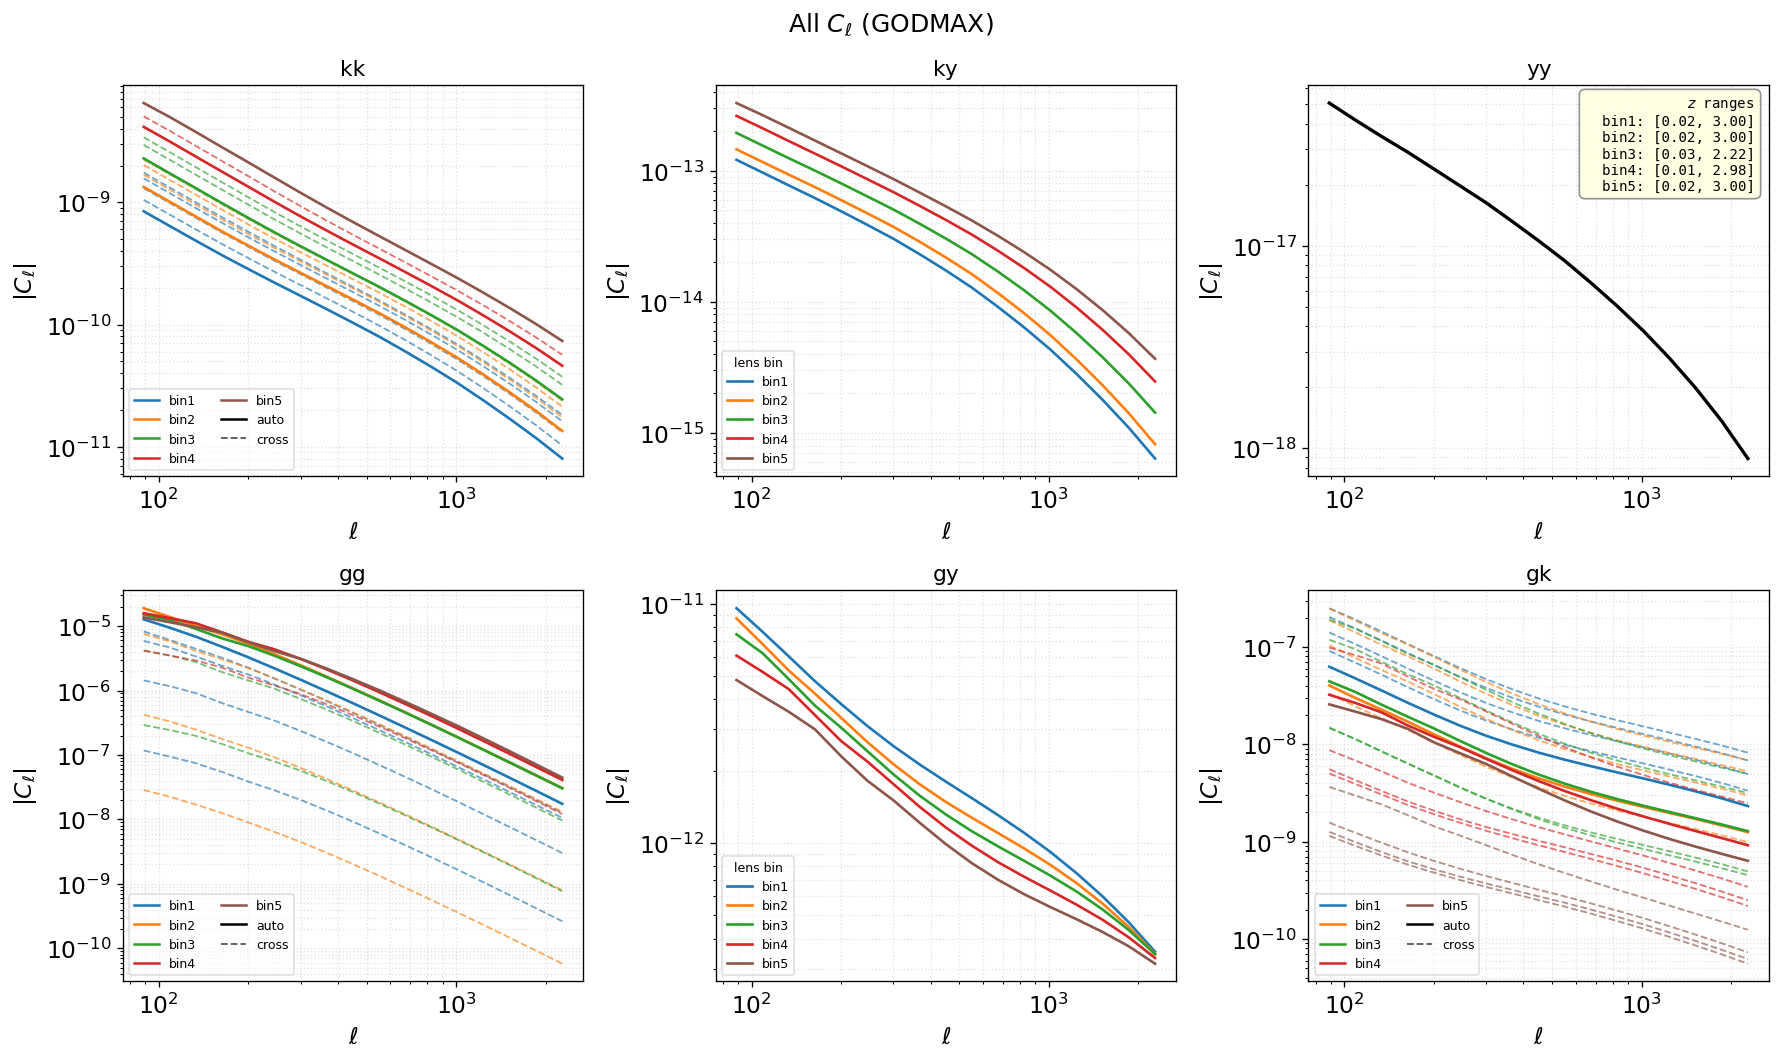

In [69]:
ell = np.array(analysis_dict['l_array_survey'])

# subtract SO LAT noise to get yy signal only
_noise_data = np.loadtxt(analysis_dict['yy_noise_ell_fname'])
_yy_noise   = np.interp(ell, _noise_data[:, 0], _noise_data[:, 1])
Cl_yy_signal = np.array(Cls_test.Cl_y_y_tot_mat) - _yy_noise

# z ranges per bin: full support where n(z) > 0
z_range = {}
for jb in range(nbins_lens):
    nz = nz_lens[jb]
    mask = nz > 0
    z_range[jb] = (float(z_lens[mask].min()), float(z_lens[mask].max()))

cmap5 = plt.cm.tab10(np.linspace(0, 0.5, nbins_lens))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
probe_order = ['kk', 'ky', 'yy', 'gg', 'gy', 'gk']

mat_attr = {
    'kk': 'Cl_kappa_kappa_tot_mat',
    'ky': 'Cl_kappa_y_tot_mat',
    'gg': 'Cl_gal_gal_tot_mat',
    'gy': 'Cl_gal_y_tot_mat',
    'gk': 'Cl_gal_kappa_tot_mat',
}

for ax, prb in zip(axes.flat, probe_order):

    if prb == 'yy':
        ax.loglog(ell, np.abs(Cl_yy_signal), 'k-', lw=2)

    else:
        mat = np.array(getattr(Cls_test, mat_attr[prb]))

        if mat.ndim == 2:                            # ky, gy → (nell, nbin)
            for b in range(mat.shape[1]):
                ax.loglog(ell, np.abs(mat[:, b]), color=cmap5[b], lw=1.6,
                          label=f'bin{b+1}')
            ax.legend(fontsize=7.5, loc='lower left', title='lens bin',
                      title_fontsize=7.5, framealpha=0.6)

        else:                                        # kk, gg, gk → (nell, nb, nb)
            from matplotlib.lines import Line2D
            nb1, nb2 = mat.shape[1], mat.shape[2]
            for b1 in range(nb1):
                b2_start = b1 if prb != 'gk' else 0
                for b2 in range(b2_start, nb2):
                    ls    = '-'   if b1 == b2 else '--'
                    lw    = 1.6   if b1 == b2 else 1.1
                    alpha = 1.0   if b1 == b2 else 0.65
                    ax.loglog(ell, np.abs(mat[:, b1, b2]),
                              color=cmap5[b1], ls=ls, lw=lw, alpha=alpha)
            leg_handles = (
                [Line2D([0],[0], color=cmap5[b], lw=1.5, label=f'bin{b+1}')
                 for b in range(nb1)] +
                [Line2D([0],[0], color='k', lw=1.5, ls='-',  label='auto'),
                 Line2D([0],[0], color='k', lw=1.1, ls='--', label='cross', alpha=0.65)]
            )
            ax.legend(handles=leg_handles, fontsize=7.5, loc='lower left',
                      framealpha=0.6, ncol=2)

    ax.set_title(prb, fontsize=13)
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel(r'$|C_\ell|$')
    ax.grid(True, which='both', ls=':', alpha=0.35)

# z-range block in yy panel
ax_yy = axes[0, 2]
z_lines = ['$z$ ranges'] + \
          [f'  bin{jb+1}: [{z_range[jb][0]:.2f}, {z_range[jb][1]:.2f}]'
           for jb in range(nbins_lens)]
ax_yy.text(0.97, 0.97, '\n'.join(z_lines),
           transform=ax_yy.transAxes, fontsize=8.5,
           va='top', ha='right', family='monospace',
           bbox=dict(boxstyle='round,pad=0.4', fc='lightyellow', ec='gray', alpha=0.85))

fig.suptitle(r'All $C_\ell$ (GODMAX)', fontsize=15)
plt.tight_layout()
plt.savefig(FIGDIR / 'all_Cls.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
def regularise(C, method, **kw):
    C = np.array(C, dtype=float)
    C = (C + C.T) / 2.0

    if method == 'original':
        return C

    if method == 'hard_threshold':
        d      = np.sqrt(np.maximum(np.diag(C), 0.0))
        d_safe = np.where(d > 0, d, 1.0)
        corr   = C / np.outer(d_safe, d_safe)
        frac   = kw.get('frac', 0.1)
        eye    = np.eye(len(C), dtype=bool)
        off    = np.abs(corr[~eye])
        s      = frac * off.max() if len(off) > 0 else 0.0
        corr_t = corr.copy()
        corr_t[(np.abs(corr) < s) & ~eye] = 0.0
        return corr_t * np.outer(d_safe, d_safe)

    eigvals, eigvecs = np.linalg.eigh(C)
    eps_mach = np.finfo(float).eps   # ~2.2e-16

    if method == 'clip_neg0':
        # Floor at eps_machine * lambda_max rather than exactly 0.
        # Flooring at 0 leaves reconstruction roundoff ~eps_mach*lambda_max
        # that shows up as tiny negative eigenvalues (~1e-29) when re-diagonalised,
        # giving cond=inf and chi2/ndof -> inf.  eps_mach floor costs nothing.
        lam = np.maximum(eigvals, eps_mach * eigvals.max())

    elif method == 'diag_shift':
        shift = max(-eigvals.min(), 0.0)
        lam   = eigvals + shift

    elif method == 'diag_shift_x11':
        eps   = 1e-10 * np.abs(eigvals).max()
        shift = max(-eigvals.min(), 0.0)
        lam   = eigvals + 1.1 * shift + eps

    elif method == 'noise_floor_01p':
        lam = eigvals + 0.001 * np.mean(np.diag(C))

    elif method == 'noise_floor_1p':
        lam = eigvals + 0.01 * np.mean(np.diag(C))

    elif method == 'cond_clamp':
        kappa_max = float(kw.get('kappa_max', 1e6))
        tau = _cond_floor(eigvals, kappa_max)
        lam = np.maximum(eigvals, tau)

    elif method == 'trunc_modes':
        n_trunc = int(kw.get('n_trunc', 1))
        lam     = eigvals.copy()
        idx_asc = np.argsort(lam)
        floor   = max(float(lam[idx_asc[n_trunc]]), 0.0) if n_trunc < len(lam) else 0.0
        lam[idx_asc[:n_trunc]] = floor

    elif method == 'lam_abs':
        # Reflect negative eigenvalues: lambda -> |lambda|
        # Bickel & Levina 2008 — congruence transform D M D with D=diag(sign(lam))
        lam = np.abs(eigvals)

    elif method == 'eig_perturb':
        # Perturb eigenvalues: lambda_new = |lambda| * (1 + delta)
        # delta ~ N(0, x/100), |delta| < 1  -> lambda_new always > 0
        # Ref: Eq.(16) of paper; x controls perturbation magnitude (default 5%)
        x   = float(kw.get('x', 5.0))
        rng = np.random.default_rng(int(kw.get('seed', 42)))
        delta = rng.normal(0.0, x / 100.0, size=len(eigvals))
        delta = np.clip(delta, -0.99, 0.99)   # |delta| < 1 strictly
        lam   = np.abs(eigvals) * (1.0 + delta)
        # floor at eps * lambda_max to avoid exact zeros
        lam   = np.maximum(lam, eps_mach * np.abs(eigvals).max())

    else:
        raise ValueError(f'Unknown regularisation method: {method!r}')

    return eigvecs @ np.diag(lam) @ eigvecs.T


In [51]:
probe_sets = [['gg'], ['gy'], ['gy','gg'], ['yy'], ['gg','kk','gk', 'gy', 'ky', 'yy']]

Cl_dict  = cov_test.Cl_result_dict
cov_dict = cov_test.covtot_dict

datavec = []
cov = []
for probes in probe_sets:
    dv, entries, nell = diag_utils.build_data_vector(Cl_dict, probes)
    cm, entries, count_per_probe, nell = diag_utils.build_cov_matrix(cov_dict, Cl_dict, probes)
    datavec.append((dv, entries, nell))
    cov.append((cm, entries, count_per_probe, nell))


In [ ]:
plt.loglog()

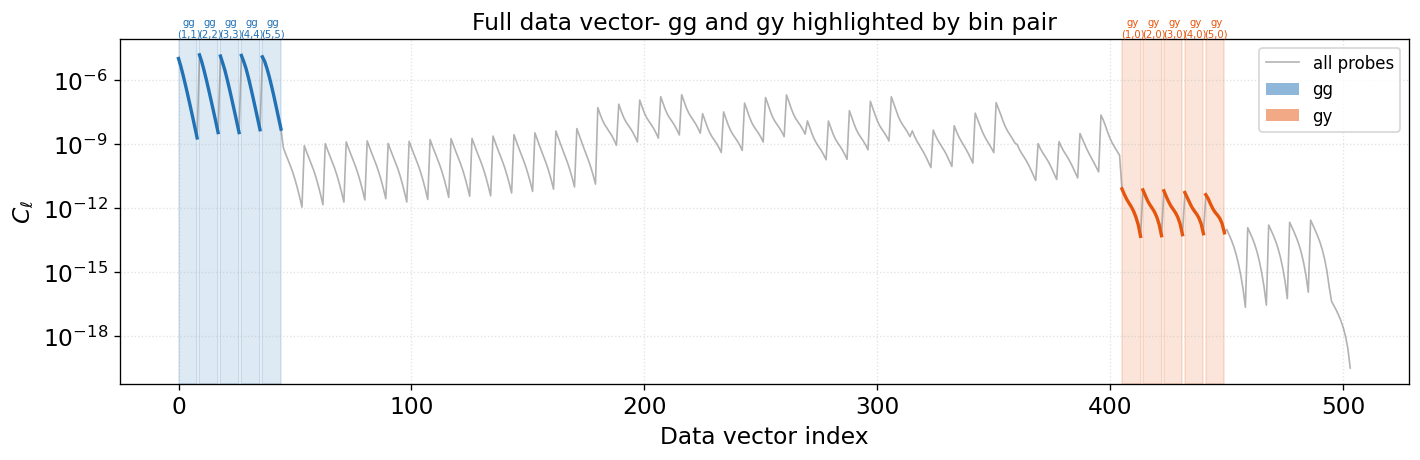

In [76]:
dv_all, entries_all, nell_all = datavec[-1]

target_probes = {"gg", "gy"}
probe_colors  = {"gg": "#2171b5", "gy": "#e6550d"}

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dv_all, lw=1.0, color='gray', alpha=0.6, label='all probes')

# shaded spans and coloured lines first
for i, (prb, (b1, b2)) in enumerate(entries_all):
    if prb in target_probes:
        c     = probe_colors[prb]
        start = i * nell_all
        end   = (i + 1) * nell_all
        ax.axvspan(start, end - 1, alpha=0.15, color=c)
        ax.plot(np.arange(start, end), dv_all[start:end], lw=2.0, color=c)

# bin-pair labels at top — after autoscale so ymax is correct
ax.set_yscale('log')
ax.relim(); ax.autoscale_view()
ymax = ax.get_ylim()[1]
for i, (prb, (b1, b2)) in enumerate(entries_all):
    if prb in target_probes:
        c   = probe_colors[prb]
        mid = (i + 0.5) * nell_all
        ax.text(mid, ymax, f'{prb}\n({b1},{b2})',
                ha='center', va='bottom', fontsize=6, color=c,
                transform=ax.transData)

from matplotlib.patches import Patch
ax.legend(handles=[
    ax.lines[0],
    Patch(facecolor=probe_colors['gg'], alpha=0.5, label='gg'),
    Patch(facecolor=probe_colors['gy'], alpha=0.5, label='gy'),
], labels=['all probes', 'gg', 'gy'], fontsize=10)

ax.set_xlabel('Data vector index')
ax.set_ylabel(r'$C_\ell$')
ax.set_title('Full data vector- gg and gy highlighted by bin pair')
ax.grid(True, which='both', ls=':', alpha=0.35)
plt.tight_layout()
plt.savefig(FIGDIR / 'data_vector_highlight_gg_gy.png', dpi=150, bbox_inches='tight')
plt.show()

probes_arr_        = ['gy', 'gg']
count_per_probe_   = [5, 5]
n_entries          = 10
cov_.shape         = (90, 90)
expected dim check = 90


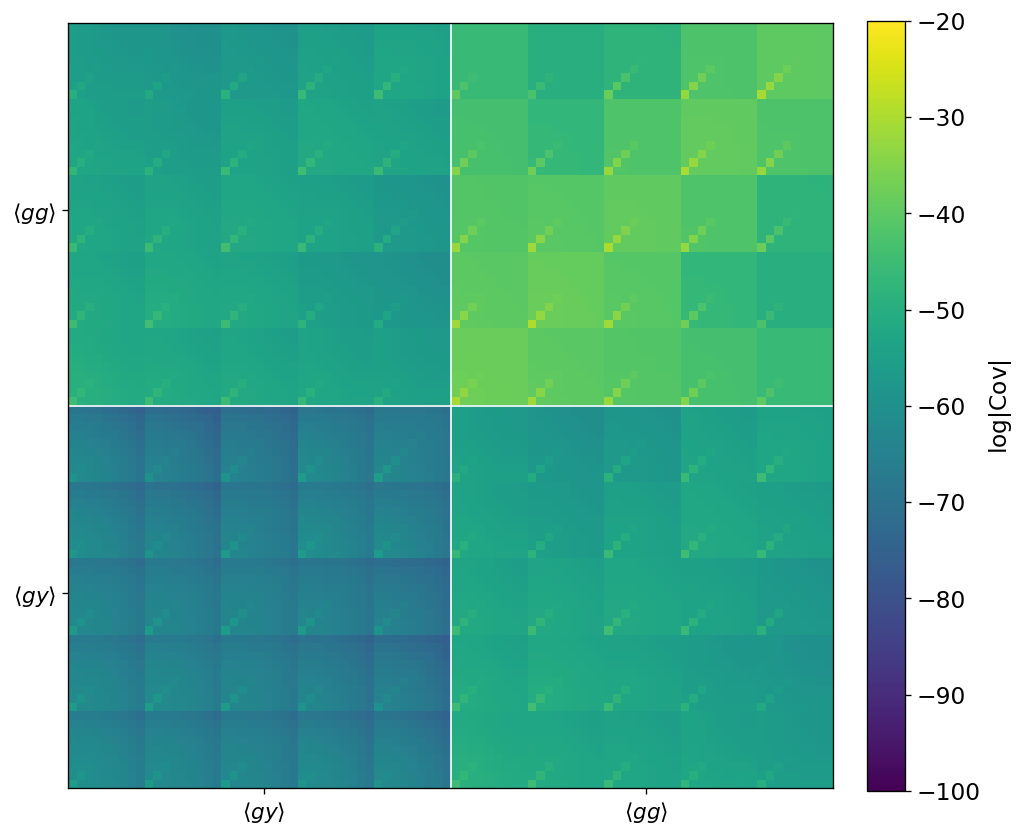

In [50]:
cov_, entries_, count_per_probe_raw, nell_ = cov[2]
probes_arr_ = probe_sets[2]   # ['gy', 'gg']

# build the counts expected by plot_cov_matrix
count_per_probe_ = [sum(e[0] == prb for e in entries_) for prb in probes_arr_]

print("probes_arr_        =", probes_arr_)
print("count_per_probe_   =", count_per_probe_)
print("n_entries          =", len(entries_))
print("cov_.shape         =", cov_.shape)
print("expected dim check =", sum(count_per_probe_) * nell_)

fig, ax = plt.subplots(figsize=(9, 9))
diag_utils.plot_cov_matrix(cov_, count_per_probe_, probes_arr_, nell_, ax=ax)
fig.savefig(FIGDIR / f"cov_{'_'.join(probes_arr_)}.png", dpi=200, bbox_inches='tight')
plt.show()

In [15]:
reg_method = 'lam_abs'

cm_reg = []
for i, probes in enumerate(probe_sets):
    dv, entries, nell = datavec[i]
    cm, entries, count_per_probe, nell = cov[i]

    cm_reg.append(regularise(cm, method=reg_method))

    import scipy.linalg

    def _safe_eigvalsh(C):
        """Eigenvalues of a symmetric matrix, with fallback and NaN/Inf guard."""
        C = np.array(C, dtype=float)
        C = (C + C.T) / 2.0          # enforce exact symmetry
        n_nan = int(np.isnan(C).sum())
        n_inf = int(np.isinf(C).sum())
        if n_nan or n_inf:
            print(f"    [WARN] matrix has {n_nan} NaNs, {n_inf} Infs — cannot decompose")
            return None
        # try numpy first, fall back to scipy with robust driver
        try:
            return np.linalg.eigvalsh(C)
        except np.linalg.LinAlgError:
            pass
        try:
            return scipy.linalg.eigvalsh(C, driver="evr")
        except Exception as e:
            print(f"    [WARN] eigvalsh failed: {e}")
            return None

    def _cond(ev):
        if ev is None: return np.inf
        pos = ev[ev > 0]
        return float(pos.max() / pos.min()) if len(pos) > 1 else np.inf

    def _diag_str(C, label):
        C = np.array(C, dtype=float)
        asym = float(np.max(np.abs(C - C.T)))
        vmin, vmax = float(np.nanmin(C)), float(np.nanmax(C))
        n_nan = int(np.isnan(C).sum())
        n_inf = int(np.isinf(C).sum())
        ev = _safe_eigvalsh(C)
        if ev is not None:
            return (f"{label}: shape={C.shape}  nan={n_nan}  inf={n_inf}  "
                    f"asym={asym:.1e}  val=[{vmin:.2e}, {vmax:.2e}]  "
                    f"cond={_cond(ev):.2e}  min_eig={ev.min():.2e}  n_neg={int((ev<0).sum())}")
        else:
            return (f"{label}: shape={C.shape}  nan={n_nan}  inf={n_inf}  "
                    f"asym={asym:.1e}  val=[{vmin:.2e}, {vmax:.2e}]  — decomposition failed")

    print(f"Probe set: {probes}")
    print("  " + _diag_str(cm,         "Original   "))
    print("  " + _diag_str(cm_reg[-1], "Regularised"))

Probe set: ['gg']
  Original   : shape=(45, 45)  nan=0  inf=0  asym=0.0e+00  val=[2.23e-22, 9.56e-14]  cond=5.96e+07  min_eig=1.87e-21  n_neg=0
  Regularised: shape=(45, 45)  nan=0  inf=0  asym=3.2e-30  val=[2.23e-22, 9.56e-14]  cond=5.96e+07  min_eig=1.87e-21  n_neg=0
Probe set: ['gy']
  Original   : shape=(45, 45)  nan=0  inf=0  asym=0.0e+00  val=[8.52e-34, 6.90e-25]  cond=9.95e+07  min_eig=1.22e-32  n_neg=0
  Regularised: shape=(45, 45)  nan=0  inf=0  asym=4.6e-41  val=[8.52e-34, 6.90e-25]  cond=9.95e+07  min_eig=1.22e-32  n_neg=0
Probe set: ['gy', 'gg']
  Original   : shape=(90, 90)  nan=0  inf=0  asym=0.0e+00  val=[8.52e-34, 9.56e-14]  cond=5.00e+18  min_eig=-6.52e-27  n_neg=9
  Regularised: shape=(90, 90)  nan=0  inf=0  asym=3.2e-30  val=[-1.28e-28, 9.56e-14]  cond=8.08e+18  min_eig=-1.73e-29  n_neg=2
Probe set: ['yy']
  Original   : shape=(9, 9)  nan=0  inf=0  asym=0.0e+00  val=[6.90e-43, 2.41e-33]  cond=5.75e+09  min_eig=5.36e-43  n_neg=0
  Regularised: shape=(9, 9)  nan=0  inf

In [27]:
# ── Global matplotlib style ───────────────────────────────────────────────────
plt.rcParams.update({
    'font.size'       : 12,
    'axes.labelsize'  : 14,
    'axes.titlesize'  : 14,
    'xtick.labelsize' : 14,
    'ytick.labelsize' : 14,
    'figure.dpi'      : 120,
    'savefig.dpi'     : 150,
    'lines.linewidth' : 2.0,
})

# ── Parameters and priors ─────────────────────────────────────────────────────
GALAXY_PARAMS = ['log10M1_fshmr', 'log10Mstar0_fshmr', 'gamma_fshmr',
                 'Bsat_Nsat', 'alphasat_Nsat']
GAS_PARAMS    = ['theta_ej_0', 'log10_Mc0', 'gamma_rhogas']
param_names   = GALAXY_PARAMS + GAS_PARAMS

prior_min = dict(log10M1_fshmr=11.5, log10Mstar0_fshmr=9.5, gamma_fshmr=0.5,
                 Bsat_Nsat=1.0, alphasat_Nsat=0.5,
                 theta_ej_0=0.5, log10_Mc0=9.0, gamma_rhogas=0.5)
prior_max = dict(log10M1_fshmr=13.5, log10Mstar0_fshmr=11.5, gamma_fshmr=4.0,
                 Bsat_Nsat=30.0, alphasat_Nsat=2.0,
                 theta_ej_0=8.0, log10_Mc0=16.0, gamma_rhogas=5.0)
latex_labels = {
    'log10M1_fshmr'    : r'\log_{10}M_1',
    'log10Mstar0_fshmr': r'\log_{10}M_{\star,0}',
    'gamma_fshmr'      : r'\gamma_{\rm SHMR}',
    'Bsat_Nsat'        : r'B_{\rm sat}',
    'alphasat_Nsat'    : r'\alpha_{\rm sat}',
    'theta_ej_0'       : r'\theta_{\rm ej,0}',
    'log10_Mc0'        : r'\log_{10}M_c',
    'gamma_rhogas'     : r'\gamma_{\rho_{\rm gas}}',
}

theta_fid_dict = {p: float(sim_params_dict[p]) for p in param_names}

# probe configs: label -> (probe list, colour)
PROBE_CONFIGS = {
    'gg'      : (['gg'],              '#2171b5'),
    'gy'      : (['gy'],              '#e6550d'),
    'yy'      : (['yy'],              "#d607ff"),
    'gg+gy'   : (['gg', 'gy'],        '#41ab5d'),
    'gy+yy'   : (['gy', 'yy'],        '#9e9ac8'),
    'gg+gy+yy': (['gg', 'gy', 'yy'], '#636363'),
}
BASE_PROBES = ['gg', 'gy', 'yy']

# step sizes for central-difference Jacobian
EPS_JAC = dict(log10M1_fshmr=0.05, log10Mstar0_fshmr=0.05, gamma_fshmr=0.05,
               Bsat_Nsat=0.5, alphasat_Nsat=0.05,
               theta_ej_0=0.1, log10_Mc0=0.1, gamma_rhogas=0.1)

def active_params(label):
    """gg→galaxy params, yy→gas params, gy or mixed→all params."""
    parts = set(label.split('+'))
    if 'gy' in parts or parts >= {'gg', 'yy'}:
        return param_names
    return GALAXY_PARAMS if 'gg' in parts else GAS_PARAMS

def extract_dv(cls_obj, entries, nell):
    """Flat data vector from a get_Cl object given an entries list."""
    out = np.zeros(len(entries) * nell)
    for idx, (prb, (b1, b2)) in enumerate(entries):
        sl = slice(idx * nell, (idx + 1) * nell)
        if   prb == 'yy': out[sl] = np.array(cls_obj.Cl_y_y_tot_mat)
        elif prb == 'gy': out[sl] = np.array(cls_obj.Cl_gal_y_tot_mat[:, b1-1])
        elif prb == 'gg': out[sl] = np.array(cls_obj.Cl_gal_gal_tot_mat[:, b1-1, b2-1])
        elif prb == 'ky': out[sl] = np.array(cls_obj.Cl_kappa_y_tot_mat[:, b1-1])
        elif prb == 'kk': out[sl] = np.array(cls_obj.Cl_kappa_kappa_tot_mat[:, b1-1, b2-1])
        elif prb == 'gk': out[sl] = np.array(cls_obj.Cl_gal_kappa_tot_mat[:, b1-1, b2-1])
    return out

for p in param_names:
    print(f'  {p:22s}  [{prior_min[p]:5.1f}, {prior_max[p]:5.1f}]  fid={theta_fid_dict[p]:.4f}')


  log10M1_fshmr           [ 11.5,  13.5]  fid=12.5500
  log10Mstar0_fshmr       [  9.5,  11.5]  fid=10.7200
  gamma_fshmr             [  0.5,   4.0]  fid=1.7900
  Bsat_Nsat               [  1.0,  30.0]  fid=9.0100
  alphasat_Nsat           [  0.5,   2.0]  fid=1.1900
  theta_ej_0              [  0.5,   8.0]  fid=2.0000
  log10_Mc0               [  9.0,  16.0]  fid=10.7500
  gamma_rhogas            [  0.5,   5.0]  fid=2.0000


### Linearised NUTS vs Fisher matrix

Both use the same Jacobian $J_{i\alpha} = \partial T_i/\partial\theta_\alpha$ and the same linearised theory $\tilde{T}(\theta) = T_{\rm fid} + J(\theta - \theta_{\rm fid})$.

**Fisher** closes analytically: the Gaussian likelihood gives $F = J^T C^{-1} J$ and the posterior is approximated as

$$p(\theta \mid d) \approx \mathcal{N}(\theta_{\rm fid},\, F^{-1})$$

which is an unbounded Gaussian — no prior, no truncation, drawn directly from $F^{-1}$.

**Linearised NUTS** samples the same Gaussian likelihood but with explicit uniform priors $\theta \in [\theta_{\rm min}, \theta_{\rm max}]$:

$$p(\theta \mid d) \propto \exp\!\left(-\tfrac{1}{2}(d - \tilde{T})^T C^{-1} (d - \tilde{T})\right) \cdot \mathbf{1}[\theta \in [\theta_{\rm min}, \theta_{\rm max}]]$$

The two agree when priors are wide and $F$ is well-conditioned. They differ when **(1)** prior boundaries truncate the posterior tails (parameters poorly constrained relative to the prior width), or **(2)** $F$ is near-singular — direct inversion amplifies conditioning errors, while NUTS adapts its mass matrix and explores degenerate directions gracefully.

In [19]:
# (helpers active_params, extract_dv defined in cell above)

In [20]:
import time, copy

nell_survey = len(cov_test.Cl_result_dict['l_array_survey'])

# entries for each atomic probe
entries_base = {}
for p in BASE_PROBES:
    _, entries_base[p], _ = diag_utils.build_data_vector(cov_test.Cl_result_dict, [p])
    print(f'[{p}]  {len(entries_base[p])} bin-pairs,  n_dv = {len(entries_base[p])*nell_survey}')

# central-difference Jacobians — 2 forward pipeline runs per parameter
J_base = {p: np.zeros((len(entries_base[p])*nell_survey, len(param_names)))
          for p in BASE_PROBES}

t0 = time.time()
for jp, param in enumerate(param_names):
    dvs = {}
    for sign in [+1, -1]:
        sp = copy.deepcopy(sim_params_dict)
        sp[param] = float(theta_fid_dict[param] + sign * EPS_JAC[param])
        tag = '+' if sign > 0 else '-'
        print(f'  [{param} {tag}]', end=' ', flush=True)
        t1 = time.time()
        cls_p = get_Cl(sp, halo_params_dict, analysis_dict, other_params_dict)
        print(f'{time.time()-t1:.1f}s')
        dvs[sign] = {p: extract_dv(cls_p, entries_base[p], nell_survey) for p in BASE_PROBES}
    for p in BASE_PROBES:
        J_base[p][:, jp] = (dvs[+1][p] - dvs[-1][p]) / (2 * EPS_JAC[param])

print(f'\nJacobians done in {time.time()-t0:.1f}s')

# assemble Jacobians for all probe-combo labels
J_all = {label: np.vstack([J_base[p] for p in probes])
         for label, (probes, _) in PROBE_CONFIGS.items()}
for label, J in J_all.items():
    print(f'  [{label}]  J shape: {J.shape}')


[gg]  5 bin-pairs,  n_dv = 45
[gy]  5 bin-pairs,  n_dv = 45
[yy]  1 bin-pairs,  n_dv = 9
  [log10M1_fshmr +] Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise
14.5s
  [log10M1_fshmr -] Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise
13.9s
  [log10Mstar0_fshmr +] Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise
14.8s
  [log10Mstar0_fshmr -] Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise
14.7s
  [gamma_fshmr +] Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise
15.5s
  [gamma_fshmr -] Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise
14.7s
  [Bsat_Nsat +] Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise
15.6s
  [Bsat_Nsat -] Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise
14.9s
  [alphasat_Nsat +] Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise
15.0s
  [alphasat_Nsat -] Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise
15.8s
  [theta_ej_0 +] Loaded yy noise from file; Cl_y_y_tot_mat = theo

## Regularisation methods

Let $C = V\Lambda V^\top$ be the eigendecomposition. All spectral methods reconstruct as $\hat{C} = V\,\mathrm{diag}(\hat{\lambda})\,V^\top$.

| Method | Formula |
|:---|:---|
| `original` | $\hat{C} = C$ |
| `clip_neg0` | $\hat{\lambda}_i = \max\!\left(\lambda_i,\; \varepsilon_\mathrm{mach}\,\lambda_\mathrm{max}\right)$ |
| `diag_shift` | $\hat{\lambda}_i = \lambda_i + \max(-\lambda_\mathrm{min},\; 0)$ |
| `diag_shift_x11` | $\hat{\lambda}_i = \lambda_i + 1.1\,\max(-\lambda_\mathrm{min},\; 0) + \varepsilon_\mathrm{abs}$ |
| `noise_floor_01p` | $\hat{\lambda}_i = \lambda_i + 10^{-3}\,\bar{\lambda}$ |
| `noise_floor_1p` | $\hat{\lambda}_i = \lambda_i + 10^{-2}\,\bar{\lambda}$ |
| `lam_abs` | $\hat{\lambda}_i = \vert\lambda_i\vert$ |
| `trunc_modes` | $\hat{\lambda}_i = \max\!\left(\lambda_i,\; \lambda_{(n+1)}\right)$, where $\lambda_{(k)}$ is the $k$-th smallest |
| `eig_perturb` | $\hat{\lambda}_i = \vert\lambda_i\vert(1+\delta_i)$, with $\delta_i\sim\mathcal{N}(0,\,(x/100)^2)$ clipped to $\vert\delta_i\vert < 1$ |
| `hard_threshold` | $\hat{r}_{ij} = r_{ij}\,\mathbf{1}[\vert r_{ij}\vert \ge s]$, where $s = f\cdot\max_{i\ne j}\vert r_{ij}\vert$ and $r_{ij} = C_{ij}/\sqrt{C_{ii}C_{jj}}$ |

**Notes:** $\bar{\lambda} = \mathrm{mean}(\mathrm{diag}(C))$; $\varepsilon_\mathrm{abs} = 10^{-10}\max\vert\lambda_i\vert$; `hard_threshold` operates on the correlation matrix.


[yy / lam_abs]  active=3  n_dv=9


sample: 100%|██████████| 2500/2500 [00:05<00:00, 469.58it/s, 31 steps of size 3.92e-02. acc. prob=0.93] 
arviz - WARNING - Shape validation failed: input_shape: (1, 2000), minimum_shape: (chains=2, draws=4)


  R-hat max = nan
                mean     sd  r_hat
theta_ej_0     2.059  0.216    NaN
log10_Mc0     11.493  1.437    NaN
gamma_rhogas   1.681  0.669    NaN
Removed no burn in

[gg / lam_abs]  active=5  n_dv=45


sample: 100%|██████████| 2500/2500 [00:03<00:00, 641.28it/s, 7 steps of size 3.70e-01. acc. prob=0.86]  
arviz - WARNING - Shape validation failed: input_shape: (1, 2000), minimum_shape: (chains=2, draws=4)


  R-hat max = nan
                     mean     sd  r_hat
log10M1_fshmr      12.549  0.028    NaN
log10Mstar0_fshmr  10.559  0.559    NaN
gamma_fshmr         1.789  0.050    NaN
Bsat_Nsat           9.671  4.064    NaN
alphasat_Nsat       1.271  0.428    NaN
Removed no burn in

[gy / lam_abs]  active=8  n_dv=45


sample: 100%|██████████| 2500/2500 [00:04<00:00, 605.51it/s, 7 steps of size 3.02e-01. acc. prob=0.80]  
arviz - WARNING - Shape validation failed: input_shape: (1, 2000), minimum_shape: (chains=2, draws=4)


  R-hat max = nan
                     mean     sd  r_hat
log10M1_fshmr      12.554  0.066    NaN
log10Mstar0_fshmr  10.721  0.418    NaN
gamma_fshmr         1.823  0.397    NaN
Bsat_Nsat          11.366  5.982    NaN
alphasat_Nsat       1.336  0.408    NaN
theta_ej_0          2.003  0.074    NaN
log10_Mc0          10.750  0.197    NaN
gamma_rhogas        1.999  0.101    NaN
Removed no burn in

[gg+gy / lam_abs]  active=8  n_dv=90


sample: 100%|██████████| 2500/2500 [00:03<00:00, 639.25it/s, 7 steps of size 2.96e-01. acc. prob=0.85]  
arviz - WARNING - Shape validation failed: input_shape: (1, 2000), minimum_shape: (chains=2, draws=4)


  R-hat max = nan
                     mean     sd  r_hat
log10M1_fshmr      12.550  0.018    NaN
log10Mstar0_fshmr  10.707  0.320    NaN
gamma_fshmr         1.790  0.037    NaN
Bsat_Nsat           9.333  3.502    NaN
alphasat_Nsat       1.224  0.397    NaN
theta_ej_0          2.002  0.035    NaN
log10_Mc0          10.756  0.137    NaN
gamma_rhogas        1.995  0.078    NaN
Removed no burn in


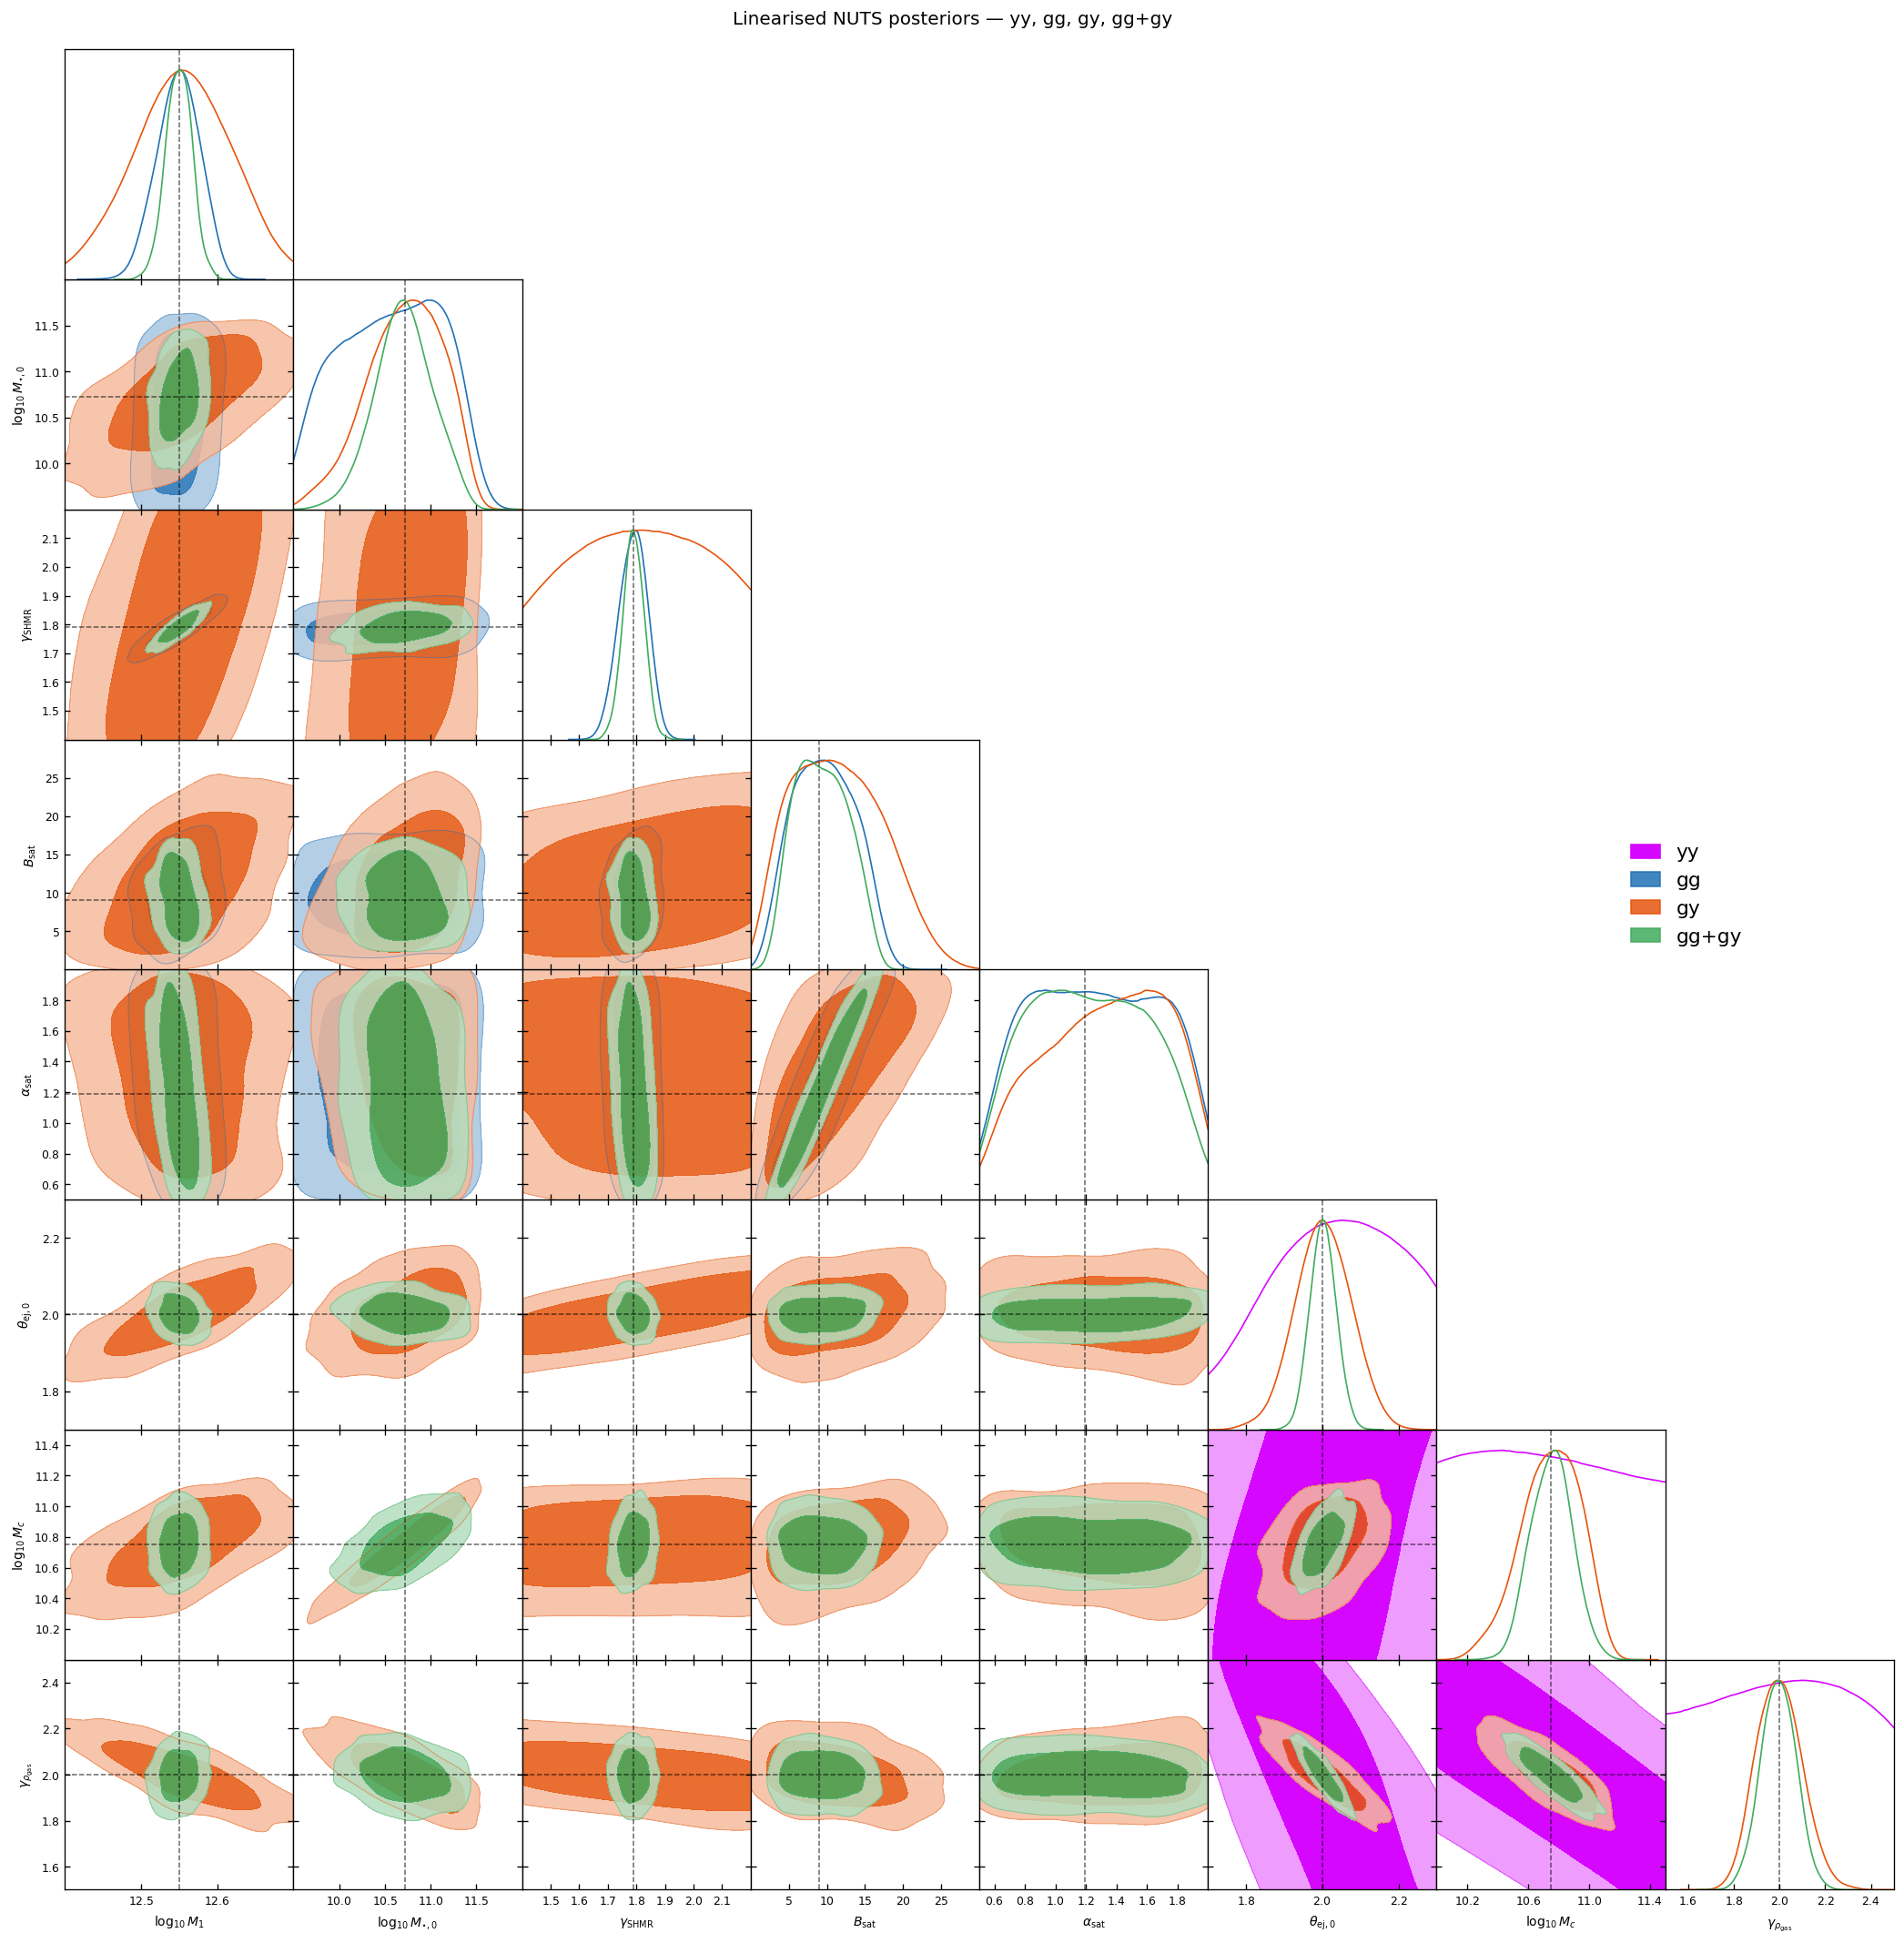


[gy / original]  active=8  n_dv=45


sample: 100%|██████████| 2500/2500 [00:04<00:00, 604.22it/s, 15 steps of size 3.04e-01. acc. prob=0.88] 
arviz - WARNING - Shape validation failed: input_shape: (1, 2000), minimum_shape: (chains=2, draws=4)


  R-hat max = nan
                     mean     sd  r_hat
log10M1_fshmr      12.554  0.071    NaN
log10Mstar0_fshmr  10.676  0.410    NaN
gamma_fshmr         1.817  0.422    NaN
Bsat_Nsat          11.159  5.834    NaN
alphasat_Nsat       1.325  0.414    NaN
theta_ej_0          2.002  0.082    NaN
log10_Mc0          10.733  0.193    NaN
gamma_rhogas        2.004  0.107    NaN
Removed no burn in

[gy / lam_abs]  active=8  n_dv=45


sample: 100%|██████████| 2500/2500 [00:04<00:00, 593.87it/s, 7 steps of size 3.02e-01. acc. prob=0.80]  
arviz - WARNING - Shape validation failed: input_shape: (1, 2000), minimum_shape: (chains=2, draws=4)


  R-hat max = nan
                     mean     sd  r_hat
log10M1_fshmr      12.554  0.066    NaN
log10Mstar0_fshmr  10.721  0.418    NaN
gamma_fshmr         1.823  0.397    NaN
Bsat_Nsat          11.366  5.982    NaN
alphasat_Nsat       1.336  0.408    NaN
theta_ej_0          2.003  0.074    NaN
log10_Mc0          10.750  0.197    NaN
gamma_rhogas        1.999  0.101    NaN
Removed no burn in

[gy / diag_shift_x11]  active=8  n_dv=45


...

  R-hat max = nan
                     mean     sd  r_hat
log10M1_fshmr      12.555  0.070    NaN
log10Mstar0_fshmr  10.697  0.417    NaN
gamma_fshmr         1.824  0.409    NaN
Bsat_Nsat          11.167  6.106    NaN
alphasat_Nsat       1.321  0.408    NaN
theta_ej_0          2.003  0.078    NaN
log10_Mc0          10.742  0.200    NaN
gamma_rhogas        2.001  0.106    NaN
Removed no burn in

[gy / eig_perturb]  active=8  n_dv=45


sample: 100%|██████████| 2500/2500 [00:04<00:00, 545.70it/s, 15 steps of size 2.76e-01. acc. prob=0.86] 
arviz - WARNING - Shape validation failed: input_shape: (1, 2000), minimum_shape: (chains=2, draws=4)


  R-hat max = nan
                     mean     sd  r_hat
log10M1_fshmr      12.557  0.072    NaN
log10Mstar0_fshmr  10.722  0.422    NaN
gamma_fshmr         1.832  0.422    NaN
Bsat_Nsat          11.408  6.064    NaN
alphasat_Nsat       1.336  0.405    NaN
theta_ej_0          2.006  0.079    NaN
log10_Mc0          10.751  0.200    NaN
gamma_rhogas        1.995  0.108    NaN
Removed no burn in

[gy / hard_threshold]  active=8  n_dv=45


sample: 100%|██████████| 2500/2500 [00:03<00:00, 647.54it/s, 7 steps of size 3.31e-01. acc. prob=0.78]  
arviz - WARNING - Shape validation failed: input_shape: (1, 2000), minimum_shape: (chains=2, draws=4)


  R-hat max = nan
                     mean     sd  r_hat
log10M1_fshmr      12.558  0.074    NaN
log10Mstar0_fshmr  10.716  0.401    NaN
gamma_fshmr         1.830  0.432    NaN
Bsat_Nsat          11.597  6.051    NaN
alphasat_Nsat       1.355  0.406    NaN
theta_ej_0          2.005  0.084    NaN
log10_Mc0          10.748  0.193    NaN
gamma_rhogas        1.997  0.110    NaN
Removed no burn in


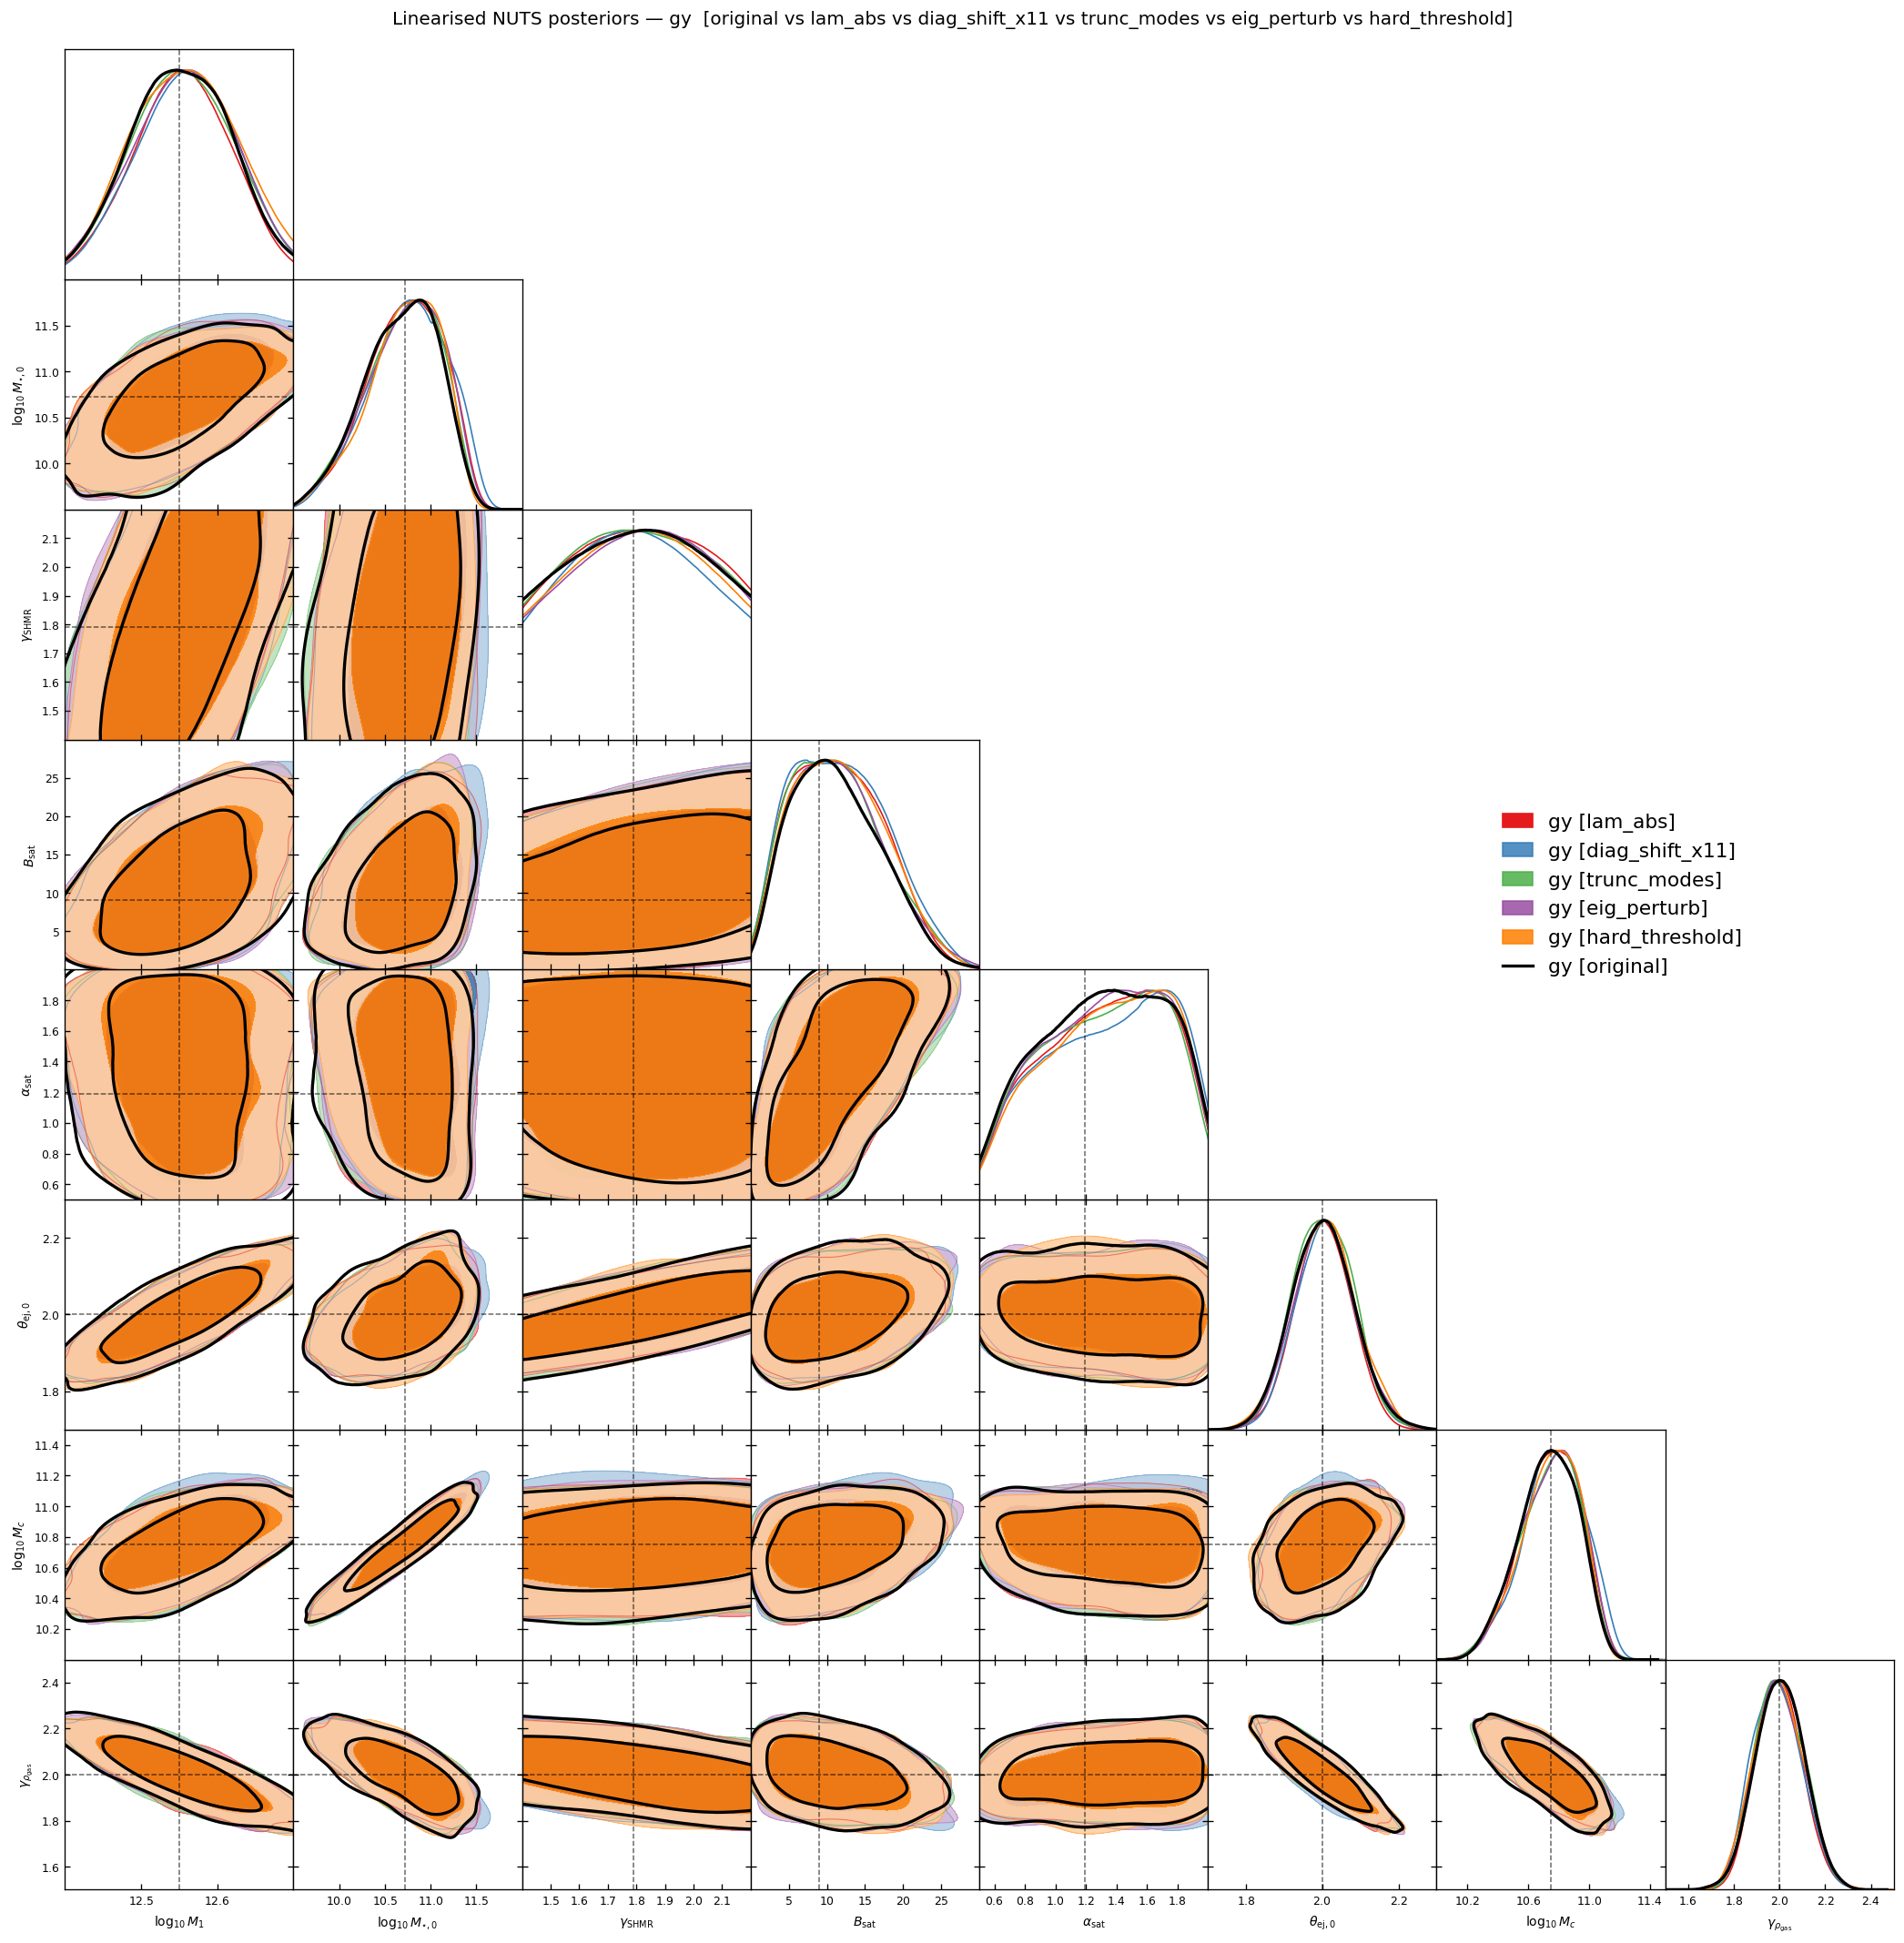

In [36]:
METHOD_COLORS = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#a65628']

DEFAULT_LIMITS = {
    'log10M1_fshmr'    : [12.4, 12.7],
    'log10Mstar0_fshmr': [9.5,  12.  ],
    'gamma_fshmr'      : [1.4,  2.2  ],
    'Bsat_Nsat'        : [0,    30.0 ],
    'alphasat_Nsat'    : [0.5,  2.0  ],
    'theta_ej_0'       : [1.7,  2.3  ],
    'log10_Mc0'        : [10.,  11.5 ],
    'gamma_rhogas'     : [1.5,  2.5  ],
}

def fisher_contours(probe_labels, reg_methods='lam_abs', n_warmup=500, n_samples=2000,
                    seed=42, param_limits=DEFAULT_LIMITS):
    """
    Linearised NUTS posteriors — uses T_fid + J dθ likelihood (fast, no full pipeline).

    probe_labels  : list of labels from PROBE_CONFIGS to overlay on one figure
    reg_methods   : str or list — regularisation methods to compare.
                    Single-probe calls get 'original' prepended automatically.
    param_limits  : dict {param_name: [lo, hi]}, defaults to DEFAULT_LIMITS.

    Probe comparison  : all filled, probe colours.
    Method comparison : reg methods filled with their colours; 'original' drawn
                        last as unfilled solid black lines (no fill).

    Returns (g, gd_all) where gd_all[(label, method)] is an MCSamples object.
    """
    if isinstance(reg_methods, str):
        reg_methods = [reg_methods]
    methods = (['original'] + reg_methods) if len(probe_labels) == 1 else reg_methods

    gd_all = {}

    for label in probe_labels:
        probes, _ = PROBE_CONFIGS[label]
        act  = active_params(label)
        aidx = [param_names.index(p) for p in act]

        cov_raw, _, _, _ = diag_utils.build_cov_matrix(
            cov_test.covtot_dict, cov_test.Cl_result_dict, probes, symmetrize=True)
        dv_fid, _, _ = diag_utils.build_data_vector(
            cov_test.Cl_result_dict, probes, key='tot_ellsurvey')

        T_fid = jnp.array(np.array(dv_fid, dtype=float))
        J_act = jnp.array(J_all[label][:, aidx])
        fid   = jnp.array([theta_fid_dict[p] for p in act])

        for method in methods:
            C_inv = np.linalg.inv(regularise(np.array(cov_raw, dtype=float), method=method))
            Cinv  = jnp.array(C_inv)

            def _model(T=T_fid, J=J_act, f=fid, Ci=Cinv, params=act):
                theta = jnp.stack([
                    numpyro.sample(p, dist.Uniform(prior_min[p], prior_max[p]))
                    for p in params
                ])
                theory_lin = T + J @ (theta - f)
                diff       = T - theory_lin
                numpyro.factor('loglike', -0.5 * diff @ Ci @ diff)

            mcmc = MCMC(
                NUTS(_model, dense_mass=True, adapt_mass_matrix=True,
                     adapt_step_size=True, max_tree_depth=8),
                num_warmup=n_warmup, num_samples=n_samples,
                num_chains=1, progress_bar=True,
            )
            print(f'\n[{label} / {method}]  active={len(act)}  n_dv={len(dv_fid)}')
            mcmc.run(jax.random.PRNGKey(seed))

            idata = az.from_numpyro(mcmc)
            summ  = az.summary(idata, var_names=act)
            print(f'  R-hat max = {summ["r_hat"].max():.4f}')
            print(summ[['mean', 'sd', 'r_hat']].to_string())

            samps = np.column_stack([np.array(mcmc.get_samples()[p]) for p in act])
            gd_all[(label, method)] = MCSamples(
                samples=samps, names=act, labels=[latex_labels[p] for p in act],
                label=f'{label}' + (f' [{method}]' if len(methods) > 1 else ''),
                settings={'smooth_scale_2D': 0.4, 'smooth_scale_1D': 0.4},
            )

    # union of active params in canonical order
    seen, params_union = set(), []
    for p in param_names:
        if any(p in active_params(lbl) for lbl in probe_labels) and p not in seen:
            params_union.append(p)
            seen.add(p)

    comparing_methods = (len(probe_labels) == 1)
    to_plot, clrs, legs, filled_list, lw_list = [], [], [], [], []

    if comparing_methods:
        # reg methods first (filled, coloured), original last (unfilled, black)
        for j, method in enumerate(methods):
            if method == 'original':
                continue
            for label in probe_labels:
                if (label, method) not in gd_all: continue
                to_plot.append(gd_all[(label, method)])
                legs.append(gd_all[(label, method)].label)
                clrs.append(METHOD_COLORS[(j - 1) % len(METHOD_COLORS)])
                filled_list.append(True)
                lw_list.append(1.0)
        for label in probe_labels:
            if (label, 'original') not in gd_all: continue
            to_plot.append(gd_all[(label, 'original')])
            legs.append(gd_all[(label, 'original')].label)
            clrs.append('black')
            filled_list.append(False)   # no fill — solid black lines only
            lw_list.append(2.0)
    else:
        for j, method in enumerate(methods):
            for label in probe_labels:
                if (label, method) not in gd_all: continue
                to_plot.append(gd_all[(label, method)])
                legs.append(gd_all[(label, method)].label)
                clrs.append(PROBE_CONFIGS[label][1])
                filled_list.append(True)
                lw_list.append(1.0)

    g = gd_plots.getSubplotPlotter(subplot_size=2.2)
    g.settings.axes_fontsize = 10
    g.settings.lab_fontsize  = 11
    g.triangle_plot(to_plot, params=params_union, filled=filled_list,
                    contour_colors=clrs, contour_lws=lw_list,
                    legend_labels=legs, param_limits=param_limits)

    # fiducial lines
    for i, p_row in enumerate(params_union):
        for j_col in range(i + 1):
            p_col = params_union[j_col]
            try:
                ax = g.subplots[i, j_col]
            except (IndexError, AttributeError):
                continue
            if ax is None: continue
            if i == j_col:
                ax.axvline(theta_fid_dict[p_col], color='k', ls='--', lw=0.9, alpha=0.6)
            else:
                ax.axvline(theta_fid_dict[p_col], color='k', ls='--', lw=0.9, alpha=0.6)
                ax.axhline(theta_fid_dict[p_row], color='k', ls='--', lw=0.9, alpha=0.6)

    # legend: center-right, bigger text
    if g.fig.legends:
        old = g.fig.legends[0]
        try:
            handles = old.legend_handles
        except AttributeError:
            handles = old.legendHandles
        labels_leg = [t.get_text() for t in old.get_texts()]
        old.remove()
        g.fig.legend(handles, labels_leg,
                     loc='center right', bbox_to_anchor=(0.92, 0.55),
                     fontsize=13, frameon=False, handlelength=1.5)

    title = ', '.join(probe_labels)
    if len(methods) > 1:
        title += '  [' + ' vs '.join(methods) + ']'
    g.fig.suptitle(f'Linearised NUTS posteriors — {title}', fontsize=12, y=1.01)
    plt.show()
    return g, gd_all


# ── compare probes (one reg method) ───────────────────────────────────────────
probe_config_test = ['yy', 'gg', 'gy', 'gg+gy']
g1, gd1 = fisher_contours(probe_config_test, reg_methods='lam_abs')

# ── compare reg methods for a single probe (reg methods filled, original black lines) ──
g2, gd2 = fisher_contours(['gy'], reg_methods=['lam_abs', 'diag_shift_x11', 'trunc_modes', 'eig_perturb', 'hard_threshold'])

# store for MCMC overlay
gd_fisher = {label: gd1[(label, 'lam_abs')]
             for label in probe_config_test if (label, 'lam_abs') in gd1}


## Full NUTS MCMC

Each step re-runs the full GODMAX pipeline. The Jacobian contours above give a fast Gaussian reference.  
Set `MCMC_LABELS` below to choose which probe combinations to sample.

In [ ]:
CHAIN_DIR = HERE / 'mcmc_chains'
CHAIN_DIR.mkdir(exist_ok=True)

NUM_WARMUP     = 5      # increase for production
NUM_SAMPLES    = 10     # increase for production
MAX_TREE_DEPTH = 5
REG_MCMC       = 'lam_abs'
MCMC_LABELS    = ['gg', 'yy', 'gy']   # subset of PROBE_CONFIGS to run

class get_Cl_quiet(get_Cl):
    """Suppress the yy-noise print during MCMC sampling."""
    def _build_cls_1h2h_dict(self): pass

def make_theory(theta_dict, entries, nell):
    """Full GODMAX forward model → flat data vector."""
    sp    = {**sim_params_dict, **theta_dict}
    base  = base_class(sp, halo_params_dict, analysis_dict, other_params_dict)
    profs = Profiles(sp, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base)
    pkz   = get_Pkz(sp, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profs)
    cls   = get_Cl_quiet(sp, halo_params_dict, analysis_dict, other_params_dict, Pkz_obj=pkz)
    return extract_dv(cls, entries, nell)

def make_model(label, data_vec, cov_reg):
    """NumPyro model for probe `label` using the full forward model."""
    act     = active_params(label)
    entries = sum([entries_base[p] for p in PROBE_CONFIGS[label][0]], [])
    C_inv   = jnp.array(np.linalg.inv(cov_reg))
    data    = jnp.array(np.array(data_vec, dtype=float))

    def _model():
        theta_d = {p: numpyro.sample(p, dist.Uniform(prior_min[p], prior_max[p]))
                   for p in act}
        theory  = jnp.array(make_theory({**theta_fid_dict, **theta_d}, entries, nell_survey))
        diff    = data - theory
        numpyro.factor('loglike', -0.5 * diff @ C_inv @ diff)
    return _model


In [ ]:
import pickle

all_idata = {}

for label in MCMC_LABELS:
    probes, color = PROBE_CONFIGS[label]
    print(f"\n{'='*50}\nNUTS — {label}\n{'='*50}")

    dv_np, _, _ = diag_utils.build_data_vector(
        cov_test.Cl_result_dict, probes, key='tot_ellsurvey')
    cov_raw, _, _, _ = diag_utils.build_cov_matrix(
        cov_test.covtot_dict, cov_test.Cl_result_dict, probes, symmetrize=True)
    cov_r = regularise(np.array(cov_raw, dtype=float), method=REG_MCMC)

    ev = np.linalg.eigvalsh(cov_r)
    print(f'  cov: min_eig={ev.min():.2e}  cond={ev.max()/max(ev.min(), 1e-300):.2e}')

    nuts = numpyro.infer.NUTS(make_model(label, dv_np, cov_r),
                              dense_mass=True, max_tree_depth=MAX_TREE_DEPTH,
                              adapt_mass_matrix=True, adapt_step_size=True)
    mcmc = numpyro.infer.MCMC(nuts, num_warmup=NUM_WARMUP, num_samples=NUM_SAMPLES,
                               num_chains=1, chain_method='sequential', progress_bar=True)
    mcmc.run(jax.random.PRNGKey(42))
    mcmc.print_summary()

    idata = az.from_numpyro(mcmc)
    all_idata[label] = idata
    act = active_params(label)
    print(f'  R-hat max = {az.summary(idata, var_names=act)["r_hat"].max():.4f}')

    chain_path = CHAIN_DIR / f'chain_{label.replace("+", "_")}.pkl'
    with open(chain_path, 'wb') as f:
        pickle.dump({k: np.array(v) for k, v in mcmc.get_samples().items()}, f)
    print(f'  Saved → {chain_path}')


In [ ]:
# ── Corner plots: MCMC (+ Fisher overlay where available) ────────────────────
for label, idata in all_idata.items():
    act   = active_params(label)
    color = PROBE_CONFIGS[label][1]

    samps = np.column_stack([np.array(idata.posterior[p].values.ravel()) for p in act])
    gd_mcmc = MCSamples(
        samples=samps, names=act, labels=[latex_labels[p] for p in act],
        label=f'{label} (MCMC)', settings={'smooth_scale_2D': 0.4, 'smooth_scale_1D': 0.4},
    )

    to_plot = [gd_mcmc];  clrs = ['gray'];  legs = [f'{label} (MCMC)']
    if label in gd_fisher:
        to_plot = [gd_fisher[label]] + to_plot
        clrs    = [color, 'gray']
        legs    = [f'{label} (Fisher)', f'{label} (MCMC)']

    g = gd_plots.getSubplotPlotter(subplot_size=2.2)
    g.settings.axes_fontsize = 10
    g.settings.lab_fontsize  = 11
    g.triangle_plot(to_plot, filled=True, contour_colors=clrs, legend_labels=legs)
    g.fig.suptitle(f'Posterior — {label}', fontsize=13, y=1.01)
    fpath = FIGDIR / f'corner_{label.replace("+", "_")}.png'
    g.export(str(fpath))
    plt.show()
    print(f'Saved {fpath}')

# ── Trace plots ────────────────────────────────────────────────────────────────
for label, idata in all_idata.items():
    act = active_params(label)
    az.plot_trace(idata, var_names=act, figsize=(12, 2.5*len(act)),
                  combined=False, compact=True)
    plt.suptitle(f'Trace — {label}', fontsize=13, y=1.01)
    plt.tight_layout()
    fpath = FIGDIR / f'trace_{label.replace("+", "_")}.png'
    plt.savefig(fpath, dpi=100, bbox_inches='tight')
    plt.show()
    print(f'Saved {fpath}')
